In [1]:
import os
from scipy.io import wavfile
import pandas as pd
import numpy as np

In [2]:
# Define the root folder containing all subfolders
root_folder = "task1/training"

# Prepare a list to store data
data = []

# Walk through all subfolders and files
for subdir, _, files in os.walk(root_folder):
    for file in files:
        if file.endswith('.wav'):
            filepath = os.path.join(subdir, file)
            sample_rate, audio = wavfile.read(filepath)
            # Store subfolder name for reference
            subfolder = os.path.basename(subdir)
            data.append({
                'filename': file,
                'patient_id': file.split('_')[0],
                'exercise': subfolder,
                'sample_rate': sample_rate,
                'audio': audio
            })

# Create a DataFrame
df = pd.DataFrame(data)

# Show the first few rows
df.head()

,filename,patient_id,exercise,sample_rate,audio
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [3]:
# Load the Excel file with patient info
excel_path = "task1/sand_task_1.xlsx"
patient_info = pd.read_excel(excel_path, usecols=["ID", "Age", "Sex", "Class"], engine="openpyxl")

# Merge patient info into your main DataFrame
df = df.merge(patient_info, left_on="patient_id", right_on="ID", how="left")

# Drop the redundant 'ID' column if desired
df = df.drop(columns=["ID"])

# Show the updated DataFrame
df.head()

,filename,patient_id,exercise,sample_rate,audio,Age,Sex,Class
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,M,5
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",61,F,5
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",51,F,4
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",59,M,3
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,F,5


In [4]:
df.describe()

,sample_rate,Age,Class
count,2176.0,2176.000000,2176.000000
mean,8000.0,63.514706,3.926471
std,0.0,11.258949,1.085799
min,8000.0,23.000000,1.000000
25%,8000.0,56.750000,3.000000
50%,8000.0,64.500000,4.000000
75%,8000.0,72.000000,5.000000
max,8000.0,89.000000,5.000000


In [5]:
# Select randomly aproximatley 20% of patient to exclude and save their ids in a excluded_patient_ids.txt file
# N.B. The patients to exclude has to be ideally balanced between classes
# Get unique patients and their class
if False:  # Change to True to run again this block (Already executed once)
    patient_classes = df.groupby('patient_id')['Class'].first().reset_index()

    # Calculate number to exclude per class
    frac = 0.2
    to_exclude = (
        patient_classes.groupby('Class', group_keys=False)
        .apply(lambda x: x.sample(frac=frac, random_state=42))
    )

    excluded_patients = to_exclude['patient_id'].values

    # Save to file
    with open('excluded_patient_ids.txt', 'w') as f:
        for patient_id in excluded_patients:
            f.write(f"{patient_id}\n")

    # Exclude patients from the DataFrame
    df = df[~df['patient_id'].isin(excluded_patients)].reset_index(drop=True)
else:
    with open('excluded_patient_ids.txt', 'r') as f:
        excluded_patients = [line.strip() for line in f]

    # Exclude patients from the DataFrame
    df = df[~df['patient_id'].isin(excluded_patients)].reset_index(drop=True)

In [6]:
df.head()

,filename,patient_id,exercise,sample_rate,audio,Age,Sex,Class
0,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",61,F,5
1,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,F,5
2,ID006_phonationA.wav,ID006,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",73,M,5
3,ID007_phonationA.wav,ID007,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",72,M,3
4,ID009_phonationA.wav,ID009,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",51,F,3


Compute spectrograms

In [7]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.utils import Sequence

class SpectrogramGenerator(Sequence):
    def __init__(self, df, patient_ids, batch_size=16,
                 n_mels=128, n_fft=1024, hop_length=512,
                 target_size=(128, 256), num_classes=3, shuffle=True,
                 augment=False, time_mask_param=20, freq_mask_param=10,
                 pitch_shift_range=2, time_stretch_range=0.1, noise_level=0.005):
        self.df = df[df['patient_id'].isin(patient_ids)].reset_index(drop=True)
        self.batch_size = batch_size
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_size = target_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.augment = augment
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.pitch_shift_range = pitch_shift_range
        self.time_stretch_range = time_stretch_range
        self.noise_level = noise_level
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            row = self.df.iloc[i]
            audio = row["audio"].astype(np.float32)
            sr = row["sample_rate"]

            # Apply audio augmentations
            if self.augment:
                audio = self.apply_audio_augment(audio, sr)

            # Compute mel spectrogram
            S = librosa.feature.melspectrogram(y=audio, sr=sr,
                                               n_mels=self.n_mels,
                                               n_fft=self.n_fft,
                                               hop_length=self.hop_length)
            S_db = librosa.power_to_db(S, ref=np.max)

            # Pad/truncate
            spec_resized = np.zeros(self.target_size, dtype=np.float32)
            freq_min = min(S_db.shape[0], self.target_size[0])
            time_min = min(S_db.shape[1], self.target_size[1])
            spec_resized[:freq_min, :time_min] = S_db[:freq_min, :time_min]

            # Apply SpecAugment
            if self.augment:
                spec_resized = self.apply_specaugment(spec_resized)

            X.append(spec_resized)
            y.append(row["class_idx"])

        X = np.array(X)[..., np.newaxis]
        y = tf.keras.utils.to_categorical(y, num_classes=self.num_classes)
        return X, y

    def apply_audio_augment(self, audio, sr):
        # Pitch shifting
        n_steps = np.random.uniform(-self.pitch_shift_range, self.pitch_shift_range)
        audio = librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)

        # Time stretching
        rate = np.random.uniform(1 - self.time_stretch_range, 1 + self.time_stretch_range)
        audio = librosa.effects.time_stretch(y=audio, rate=rate)

        # Add Gaussian noise
        noise = np.random.randn(len(audio)) * self.noise_level
        audio = audio + noise
        return audio

    def apply_specaugment(self, mel):
        # Time masking
        t = np.random.randint(0, self.time_mask_param)
        t0 = np.random.randint(0, max(1, mel.shape[1] - t))
        mel[:, t0:t0+t] = 0

        # Frequency masking
        f = np.random.randint(0, self.freq_mask_param)
        f0 = np.random.randint(0, max(1, mel.shape[0] - f))
        mel[f0:f0+f, :] = 0
        return mel

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [8]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback

class F1ScoreCallback(Callback):
    def __init__(self, train_gen, val_gen):
        super().__init__()
        self.train_gen = train_gen
        self.val_gen = val_gen
        self.f1_scores = {"train": [], "val": []}

    def on_epoch_end(self, epoch, logs=None):
        # Compute predictions on train
        y_true_train = self.train_gen.df["class_idx"].values
        y_pred_train = np.argmax(self.model.predict(self.train_gen, verbose=0), axis=1)
        f1_train = f1_score(y_true_train, y_pred_train, average="macro")

        # Compute predictions on val
        y_true_val = self.val_gen.df["class_idx"].values
        y_pred_val = np.argmax(self.model.predict(self.val_gen, verbose=0), axis=1)
        f1_val = f1_score(y_true_val, y_pred_val, average="macro")

        # Save for later plotting
        self.f1_scores["train"].append(f1_train)
        self.f1_scores["val"].append(f1_val)

        # Print progress
        print(f" — val_f1: {f1_val:.3f} — train_f1: {f1_train:.3f}")

import matplotlib.pyplot as plt

def plot_training_history_with_f1(history, f1_callback):
    hist = history.history

    plt.figure(figsize=(15, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # F1 Score
    plt.subplot(1, 3, 3)
    plt.plot(f1_callback.f1_scores["train"], label="Train F1 (macro)")
    plt.plot(f1_callback.f1_scores["val"], label="Val F1 (macro)")
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.title('F1 Score over Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Encode labels
# -----------------------------
label_encoder = LabelEncoder()
df['class_idx'] = label_encoder.fit_transform(df['Class'])
num_classes = df['class_idx'].nunique()

# -----------------------------
# Patient-level stratified split
# -----------------------------
patient_ids = df['patient_id'].unique()
patient_classes = df.groupby('patient_id')['class_idx'].first().values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(patient_ids, patient_classes, groups=patient_ids))

train_patients = patient_ids[train_idx]
val_patients = patient_ids[val_idx]

# -----------------------------
# Generators with higher resolution
# -----------------------------
train_gen = SpectrogramGenerator(df, train_patients, batch_size=16,
                                 n_mels=128, target_size=(128,256),
                                 num_classes=num_classes, shuffle=True,
                                 augment=True)

val_gen = SpectrogramGenerator(df, val_patients, batch_size=16,
                               n_mels=128, target_size=(128,256),
                               num_classes=num_classes, shuffle=False,
                               augment=False)

# -----------------------------
# Residual block
# -----------------------------
def residual_block(x, filters, kernel_size=3, stride=1, dropout=0.3, l2_reg=1e-4):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding="same",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, strides=1, padding="same",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)

    # Add shortcut connection
    if shortcut.shape[-1] != x.shape[-1]:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout)(x)
    return x

# -----------------------------
# CNN Model
# -----------------------------
def build_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    x = residual_block(inputs, 32)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2,2))(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling2D((2,2))(x)
    
    x = residual_block(x, 256)
    
    # Combine GlobalAvg + GlobalMax pooling
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = keras.Model(inputs, outputs)
    return model

input_shape = (128, 256, 1)
model = build_cnn(input_shape, num_classes)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# Callbacks
# -----------------------------
f1_callback = F1ScoreCallback(train_gen, val_gen)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    f1_callback
]

# -----------------------------
# Training
# -----------------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 256,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 256,  │         64 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 256,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 256,  │          0 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 256,  │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 256,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 256,  │      2,112 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        256 │ conv2d_4[0][0]  

 Total params: 1,287,269 (4.91 MB)

 Trainable params: 1,284,389 (4.90 MB)

 Non-trainable params: 2,880 (11.25 KB)

c:\Users\adriano.minora\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3063 - loss: 4.0728

c:\Users\adriano.minora\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 — val_f1: 0.255 — train_f1: 0.164
88/88 ━━━━━━━━━━━━━━━━━━━━ 779s 9s/step - accuracy: 0.3063 - loss: 4.0548 - val_accuracy: 0.2500 - val_loss: 1.5462 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3336 - loss: 1.5060 — val_f1: 0.156 — train_f1: 0.110
88/88 ━━━━━━━━━━━━━━━━━━━━ 735s 8s/step - accuracy: 0.3337 - loss: 1.5057 - val_accuracy: 0.4545 - val_loss: 1.3768 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3534 - loss: 1.5036 — val_f1: 0.156 — train_f1: 0.110
88/88 ━━━━━━━━━━━━━━━━━━━━ 723s 8s/step - accuracy: 0.3535 - loss: 1.5033 - val_accuracy: 0.4545 - val_loss: 1.3494 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3797 - loss: 1.4657 — val_f1: 0.156 — train_f1: 0.110
88/88 ━━━━━━━━━━━━━━━━━━━━ 693s 8s/step - accuracy: 0.3795 - loss: 1.4656 - val_accuracy: 0.4545 - val_loss: 1.3595 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - acc

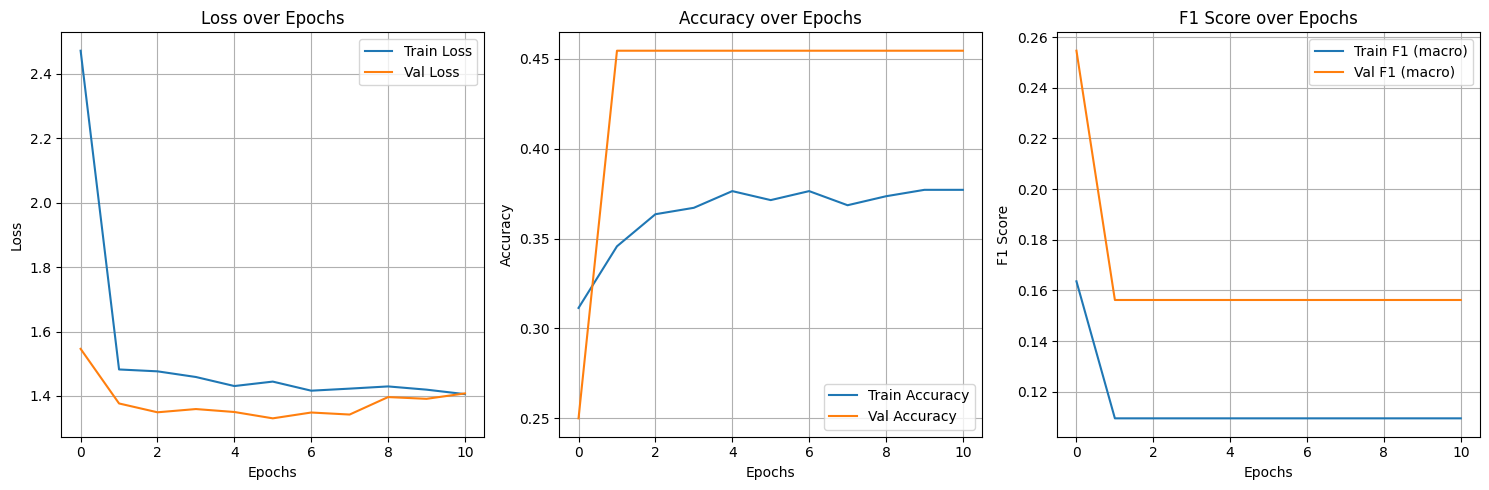

In [10]:
plot_training_history_with_f1(history, f1_callback)

In [11]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, generator, class_names, title="Confusion Matrix"):
    # Force deterministic ordering (important!)
    generator.shuffle = False  

    # True labels (already aligned with df order)
    y_true = generator.df["class_idx"].values

    # Predict in order
    print("Computing predictions...")
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Sanity check: lengths must match
    assert len(y_true) == len(y_pred), "Mismatch between true and predicted labels!"

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute F1 score
    f1 = f1_score(y_true, y_pred, average="macro")

    # Plot
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} (Macro F1 = {f1:.3f})")
    plt.show()

def make_eval_generator(train_gen, shuffle=False):
    """
    Clone a SpectrogramGenerator with the same parameters but optionally no shuffle.
    Useful for evaluation (confusion matrix, F1, etc.).
    """
    return SpectrogramGenerator(
        df=train_gen.df,                     # same filtered dataframe
        patient_ids=train_gen.df['patient_id'].unique(),  # same patients
        batch_size=train_gen.batch_size,
        n_mels=train_gen.n_mels,
        n_fft=train_gen.n_fft,
        hop_length=train_gen.hop_length,
        target_size=train_gen.target_size,
        num_classes=train_gen.num_classes,
        shuffle=shuffle
    )


In [12]:
# -----------------------------
# Class names (in order of label encoder)
class_names = label_encoder.classes_

Computing predictions...


c:\Users\adriano.minora\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


88/88 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step


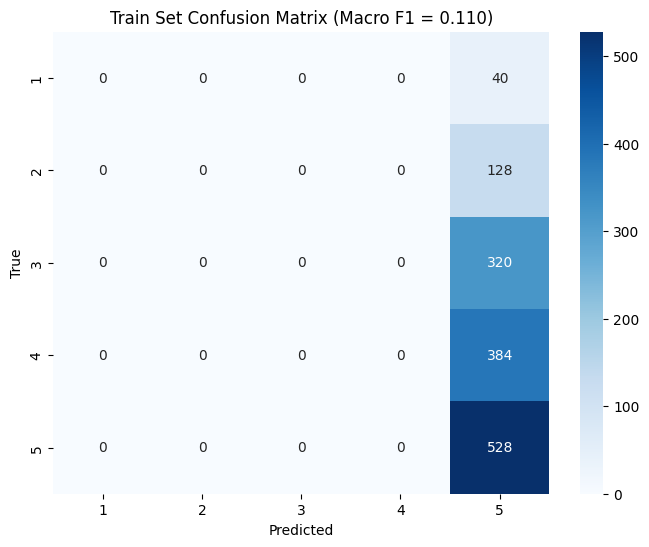

Computing predictions...


c:\Users\adriano.minora\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step


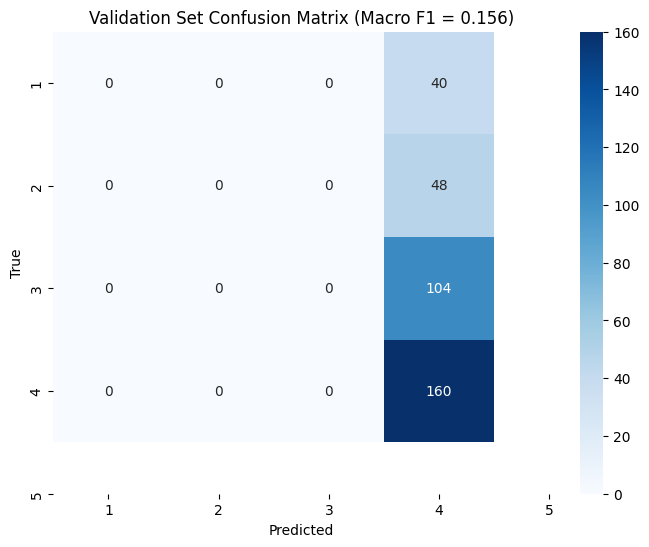

In [13]:
# Create fixed-order generators for evaluation
train_gen_eval = make_eval_generator(train_gen, shuffle=False)
val_gen_eval   = make_eval_generator(val_gen, shuffle=False)

# Now safe to evaluate
plot_confusion_matrix(model, train_gen_eval, class_names, "Train Set Confusion Matrix")
plot_confusion_matrix(model, val_gen_eval, class_names, "Validation Set Confusion Matrix")
